<a href="https://colab.research.google.com/github/Angelorigo/MODELOS-ESTOCASTICOS/blob/main/Algoritmo_para_simular_una_Cadena_de_Markov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#**ÁLVAREZ SERVÍN ÁNGEL RODRIGO**

##- MATEMÁTICA ALGORÍTMICA.
##- MODELOS ESTOCÁSTICOS.
##- ESFM IPN, MARZO 2026.

Este programa está basado en el juego porpuesto al inicio del curso sobre una ficha en un tablero de cuatro colores, por lo que dada una distribución inicial, y su matriz de transición P, se haga una caminata aleatoria 100 veces y calcular su probabilidad acumulada.

Se pidió que fuera con 100 pasos pero las probabilidades acumuladas tienden a 0 y no se visualiza bien la gráfica, así que lo cambié a 20, en caso de querer graficar los 100 pasos, cambie el valor de n en la línea 28.

Como siempre, se declaran las librerías:

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

Luego definimos la matriz de transición P, donde las columnas representan el color acutal, y las filas, el siguiente; también definimos las opciones, que son los colores, y el número de tiradas:

In [ ]:
# [A = Azul, N = Naranja, R = Rojo, V = Verde]

P = np.array ([[0.25, 0.00, 0.25, 0.50],
               [0.50, 0.25, 0.00, 0.25],
               [0.25, 0.50, 0.25, 0.00],
               [0.00, 0.25, 0.50, 0.25]])


colores = ['A', 'N', 'R', 'V']
n = 20

Ahora se imprime para el usuario el vector de valores iniciales para los estados:

In [ ]:
a = np.array([0.25, 0.25, 0.25, 0.25])
print(f"===========================================================================")
print(f"          Tu vector de valores iniciales es: {a}")
print(f"===========================================================================\n")
print(f"    Considere: A = Azul, N = Naranja, R = Rojo, V = Verde")
X = []  # X Guarda el camino

          Tu vector de valores iniciales es: [0.25 0.25 0.25 0.25]

    Considere: A = Azul, N = Naranja, R = Rojo, V = Verde


En esta parte se hace uso de la librería "random" para determinar valores aleatorios que tomará la caminata en cada iteración:

In [ ]:
X_0 = np.random.choice([0, 1, 2, 3], p = a)
X.append(X_0)

Cálculo de la Probabilidad Acumulada, denotada PA:

In [ ]:
PA = a[X_0]

Bucle:

In [ ]:
print(f"---------------------------------------------------------------------------")
for i in range (1, n+1):
    j = X[i-1]
    p = P[j, :]
    X_i = np.random.choice([0, 1, 2, 3], p=p)
    X.append(X_i)
    PA *= P[j, X_i]
    print(f"{i}, de {colores[j]}, a {colores[X_i]}; Con probabilidad: {P[j, X_i]}")
    print(f"---------------------------------------------------------------------------")

camino = [colores[estado] for estado in X]

---------------------------------------------------------------------------
1, de N, a A; Con probabilidad: 0.5
---------------------------------------------------------------------------
2, de A, a R; Con probabilidad: 0.25
---------------------------------------------------------------------------
3, de R, a N; Con probabilidad: 0.5
---------------------------------------------------------------------------
4, de N, a A; Con probabilidad: 0.5
---------------------------------------------------------------------------
5, de A, a A; Con probabilidad: 0.25
---------------------------------------------------------------------------
6, de A, a R; Con probabilidad: 0.25
---------------------------------------------------------------------------
7, de R, a N; Con probabilidad: 0.5
---------------------------------------------------------------------------
8, de N, a A; Con probabilidad: 0.5
---------------------------------------------------------------------------
9, de A, a V; Con probabi

Impresión del Camino recorrido:

In [ ]:
print(f"\n===========================================================================")
print(f"La trayectoria fue:\n{' -> '.join(camino)}")
print(f"===========================================================================")
print(f"Probabilidad de llegar a este evento, dado el camino anterior: {PA:.20f}")
print(f"===========================================================================")


La trayectoria fue:
N -> A -> R -> N -> A -> A -> R -> N -> A -> V -> R -> N -> V -> N -> A -> V -> R -> A -> V -> R -> R
Probabilidad de llegar a este evento, dado el camino anterior: 0.00000000186264514923


Graficación de los estados:

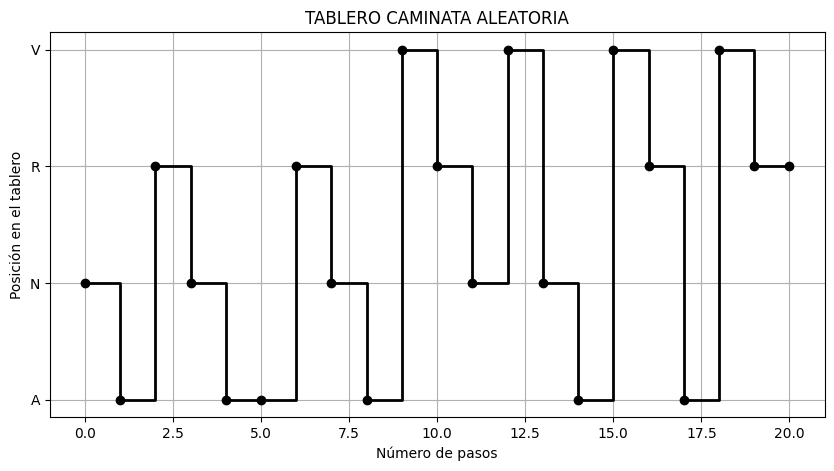

In [ ]:
plt.figure(figsize=(10, 5))
plt.step(range(n+1), X, where = 'post', marker = 'o', color = 'black', linewidth = 2)
plt.yticks([0, 1, 2, 3], colores)
plt.xlabel("Número de pasos")
plt.ylabel("Posición en el tablero")
plt.title("TABLERO CAMINATA ALEATORIA")
plt.grid(True)
plt.show()
